# 05 · Evaluación

**Fase CRISP-DM:** evaluación.

**Objetivo.** Evaluar la técnica elegida **una sola vez** sobre los bloques de prueba reservados, calcular la brecha
entre consultas observadas y esperadas por zona, contrastarla con la cobertura de la red mapeada y medir su
estabilidad ante variaciones metodológicas razonables.

| | |
|---|---|
| **Entradas** | `tabla_modelado.parquet`, `resultados/04_modelado/modelo_final.joblib` y `metricas.json` de las fases 02 y 04 |
| **Salidas** | `resultados/05_evaluacion/`: métricas de prueba, calibración, `brecha_por_zona.csv`, contraste GTFS, sensibilidad, figuras y `metricas.json` |

## 1. Configuración

In [1]:
import sys
from pathlib import Path

RAIZ = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
sys.path.insert(0, str(RAIZ))

In [2]:
from src.entorno import *  # noqa: F403
from src import espacial, evaluacion as ev, modelos as mo

import joblib

FASE = "05_evaluacion"
limpiar_salidas(FASE)
M = {}
tiempo = cronometro()

## 2. Carga
**Tipo de datos:** tabulares por zona y el modelo ajustado.

Se separan entrenamiento y prueba con la marca `in_test` de la tabla y se carga la técnica elegida en el modelado.
`W_obs` (semanas observadas) viene del preprocesamiento.

In [3]:
tabla = pl.read_parquet(config.TABLA_MODELADO).filter(pl.col("in_model")).to_pandas()
entreno, prueba = tabla[~tabla["in_test"]].reset_index(drop=True), tabla[tabla["in_test"]].reset_index(drop=True)
modelado = leer_metricas("04_modelado")
ELEGIDA, W_OBS = modelado["tecnica_elegida"], leer_metricas("02_preprocesamiento")["w_obs_semanas"]
final = joblib.load(config.RESULTADOS / "04_modelado" / "modelo_final.joblib")
print(f"Técnica: {mo.NOMBRE[ELEGIDA]} | entrenamiento {len(entreno):,} zonas | prueba {len(prueba):,} zonas | W_obs = {W_OBS}")

Técnica: B3 · vecindad H3 | entrenamiento 1,029 zonas | prueba 352 zonas | W_obs = 81.143


## 3. Evaluación única en la prueba
**Tipo de datos:** numéricos (métricas de conteo).

Se predice la prueba con el modelo final. La tasa global (B0) ajustada en el mismo entrenamiento es la referencia
mínima: el **D² frente a la tasa global** dice cuánto mejora la técnica respecto de suponer que las consultas solo
dependen de la población. Las métricas se comparan con las de la validación cruzada.

In [4]:
esperado_prueba = np.maximum(final.predict(prueba), mo.EPS)
referencia = mo.B0().fit(entreno).predict(prueba)
m = mo.metricas(prueba["query_count"], esperado_prueba)
m["d2_frente_tasa_global"] = ev.d2_frente_a(prueba["query_count"], esperado_prueba, referencia)
cv = pd.read_csv(config.RESULTADOS / "04_modelado" / "cv_resumen.csv").set_index("tecnica").loc[ELEGIDA]
tabla_prueba = pd.DataFrame({"metrica": ["devianza_poisson", "d2", "mae", "spearman", "calibracion", "d2_frente_tasa_global"]})
tabla_prueba["prueba"] = tabla_prueba["metrica"].map(m)
tabla_prueba["cv_media"] = tabla_prueba["metrica"].map(lambda k: cv.get(f"{k}_media", cv.get(f"oof_{k}", np.nan)))
tabla_prueba["cv_de"] = tabla_prueba["metrica"].map(lambda k: cv.get(f"{k}_de", np.nan))
M.update({f"prueba_{k}": round(float(v), 3) for k, v in m.items() if k != "n"})
guardar_tabla(tabla_prueba.round(4), "metricas_prueba", FASE)

,metrica,prueba,cv_media,cv_de
0,devianza_poisson,1086.4721,1389.2900,1944.0500
1,d2,0.4583,0.7299,0.1401
2,mae,428.0526,1212.5700,1619.2400
3,spearman,0.8799,0.7990,0.0403
4,calibracion,0.5972,0.9766,NaN
5,d2_frente_tasa_global,0.5025,NaN,NaN


La calibración por deciles agrupa las zonas de prueba por su conteo esperado y compara, en cada grupo, la suma
observada con la esperada. Una razón cercana a 1 en todos los deciles indica que el modelo no sobre- ni subestima de
forma sistemática según el tamaño de la zona.

⏱ prueba: 1.2 s (acumulado 1 s)


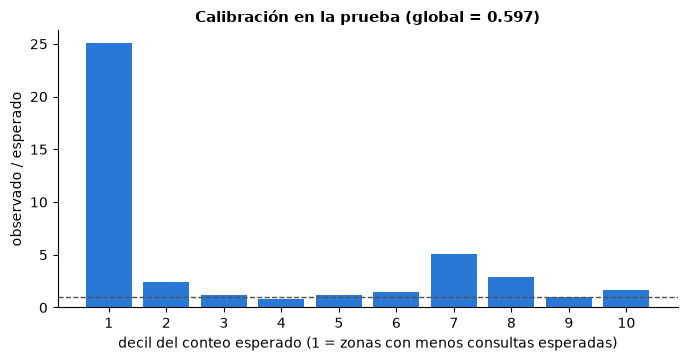

In [5]:
deciles = guardar_tabla(ev.calibracion_por_deciles(prueba["query_count"], esperado_prueba).round(4), "calibracion_deciles", FASE)
fig, ax = plt.subplots(figsize=(8, 3.6))
ax.bar(deciles["decil"], deciles["razon_obs_esp"], color=AZUL)
ax.axhline(1, color=TINTA, ls="--", lw=1)
ax.set(xlabel="decil del conteo esperado (1 = zonas con menos consultas esperadas)", ylabel="observado / esperado",
       title=f"Calibración en la prueba (global = {M['prueba_calibracion']})", xticks=range(1, 11))
guardar_figura(fig, "calibracion_deciles", FASE)
tiempo("prueba")

## 4. Brecha por zona
**Tipo de datos:** numéricos por zona (observado, esperado y brecha) y espaciales (mapa).

El esperado de cada zona se calcula **sin que la zona se vea a sí misma**: en entrenamiento, con las predicciones fuera
de pliegue de la validación por bloques; en prueba, con el modelo final. Con él se calcula:

| Columna | Definición | Lectura |
|---|---|---|
| `expected_week` | esperado / `W_obs` | consultas esperadas por semana observada |
| `gap_pearson` | (obs − esp) / √esp | brecha comparable entre zonas; negativa = menos consultas de las esperadas |
| `ratio_obs_exp` | (obs + 1) / (esp + 1) | razón contraída hacia 1 en zonas con pocos conteos |
| `unmet_demand` | max(esp − obs, 0) | consultas esperadas que no se registraron |

También se calcula la brecha frente a la tasa global (`gap_pearson_global`), que ignora el contexto territorial.

In [6]:
esp = mo.esperado_por_zona(entreno, prueba, ELEGIDA)
esp_global = mo.esperado_por_zona(entreno, prueba, "B0").rename(columns={"esperado": "esperado_global"})
cols = ["h3_cell", "municipality", "population", "query_count", "dist_centro_km", "dist_trazado_m", "gtfs_covered", "lat", "lon"]
brecha = tabla[cols].merge(esp, on="h3_cell").merge(esp_global[["h3_cell", "esperado_global"]], on="h3_cell")
brecha = brecha.rename(columns={"query_count": "observed", "esperado": "expected", "particion": "partition"})
brecha["expected_week"] = brecha["expected"] / W_OBS
brecha = pd.concat([brecha, ev.brecha(brecha["observed"], brecha["expected"])], axis=1)
brecha["gap_pearson_global"] = ev.brecha(brecha["observed"], brecha.pop("esperado_global"))["gap_pearson"]
brecha = brecha.sort_values("h3_cell", ignore_index=True)
guardar_tabla(brecha.round(4), "brecha_por_zona", FASE)
brecha.sort_values("gap_pearson").head(5)

,h3_cell,municipality,population,observed,dist_centro_km,dist_trazado_m,gtfs_covered,lat,lon,expected,partition,expected_week,gap_pearson,ratio_obs_exp,unmet_demand,gap_pearson_global
367,888b2c886bfffff,Sacaba,2983,2002,5.2281,26.5,1,-17.366707,-66.116589,53661.398907,entrenamiento,661.318893,-223.006927,0.037326,51659.398907,-16.331592
351,888b2c8845fffff,Sacaba,3548,6787,4.4612,137.7,1,-17.374739,-66.119899,56453.482441,entrenamiento,695.728312,-209.034531,0.120238,49666.482441,57.490075
352,888b2c8847fffff,Sacaba,3423,3148,4.4102,46.1,1,-17.368128,-66.125143,25201.050304,entrenamiento,310.575777,-138.918264,0.124950,22053.050304,-2.691928
493,888b2c8ae9fffff,Cochabamba,4876,23054,1.8962,13.8,1,-17.383262,-66.171239,55128.562255,entrenamiento,679.400099,-136.606827,0.418197,32074.562255,154.669907
489,888b2c8ae1fffff,Cochabamba,5019,23758,2.3465,74.7,1,-17.375229,-66.167926,55398.662834,entrenamiento,682.728798,-134.429917,0.428865,31640.662834,157.216920


Resumen de la brecha: cuántas zonas tienen menos consultas de las esperadas, cuánta demanda no resuelta estimada hay
en total y qué parte concentran las `TOP_K` zonas de mayor brecha negativa.

In [7]:
top = ev.top_k(brecha)
M.update({"zonas_brecha": len(brecha), "zonas_bajo_esperado": int((brecha["gap_pearson"] < 0).sum()),
          "zonas_brecha_menor_menos2": int((brecha["gap_pearson"] < -2).sum()),
          "demanda_no_resuelta_total": round(float(brecha["unmet_demand"].sum())),
          "pct_demanda_no_resuelta_top_k": round(float(brecha.loc[brecha["h3_cell"].isin(top), "unmet_demand"].sum()
                                                      / brecha["unmet_demand"].sum() * 100), 1),
          "pct_zonas_top_k": round(len(top) / len(brecha) * 100, 2)})
print({k: M[k] for k in ("zonas_brecha", "zonas_bajo_esperado", "zonas_brecha_menor_menos2", "demanda_no_resuelta_total",
                         "pct_demanda_no_resuelta_top_k", "pct_zonas_top_k")})

{'zonas_brecha': 1381, 'zonas_bajo_esperado': 923, 'zonas_brecha_menor_menos2': 457, 'demanda_no_resuelta_total': 641937, 'pct_demanda_no_resuelta_top_k': 60.2, 'pct_zonas_top_k': 1.45}


PosixPath('/home/robvox/Desktop/trufi-data-science/resultados/05_evaluacion/figuras/observado_vs_esperado.png')

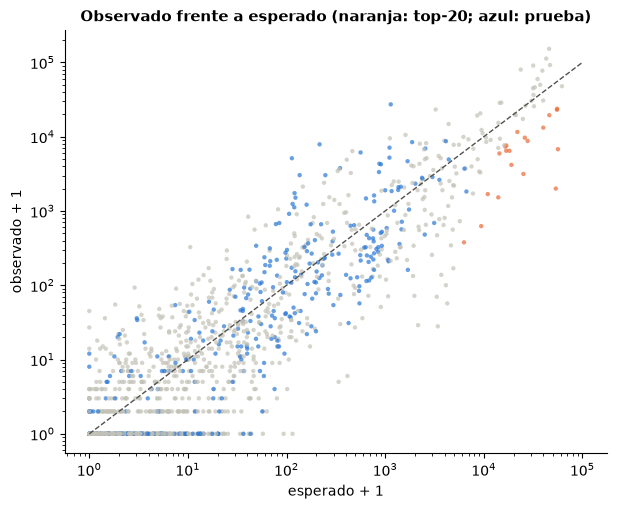

In [8]:
fig, ax = plt.subplots(figsize=(7, 5.5))
color = np.where(brecha["h3_cell"].isin(top), NARANJA, np.where(brecha["partition"] == "prueba", AZUL, GRIS))
ax.scatter(brecha["expected"] + 1, brecha["observed"] + 1, s=10, c=color, alpha=0.7, lw=0)
ax.plot([1, 1e5], [1, 1e5], color=TINTA, ls="--", lw=1)
ax.set(xscale="log", yscale="log", xlabel="esperado + 1", ylabel="observado + 1",
       title=f"Observado frente a esperado (naranja: top-{config.TOP_K}; azul: prueba)")
guardar_figura(fig, "observado_vs_esperado", FASE)

⏱ brecha: 5.5 s (acumulado 7 s)


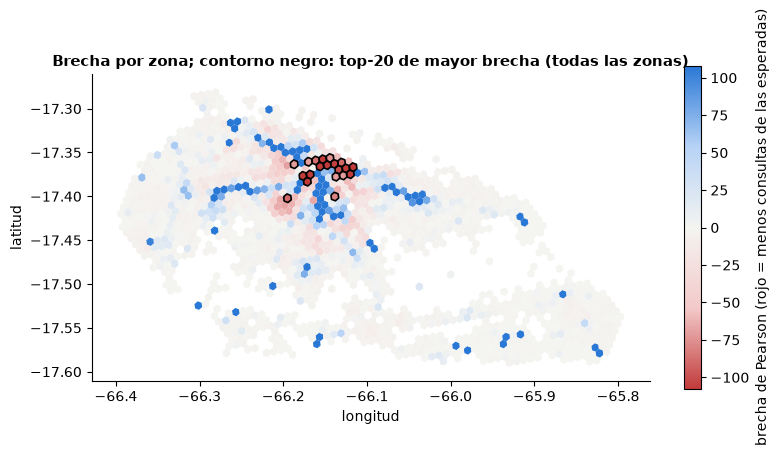

In [9]:
geo = espacial.geo_zonas(brecha[["h3_cell", "gap_pearson"]])
lim = float(np.percentile(np.abs(geo["gap_pearson"]), 95))
fig, ax = plt.subplots(figsize=(9, 7))
geo.plot(ax=ax, column="gap_pearson", cmap=DIVERGENTE, vmin=-lim, vmax=lim, edgecolor="none", legend=True,
         legend_kwds={"label": "brecha de Pearson (rojo = menos consultas de las esperadas)", "shrink": 0.6})
geo[geo["h3_cell"].isin(top)].boundary.plot(ax=ax, color="black", lw=1.2)
ax.set(xlabel="longitud", ylabel="latitud", title=f"Brecha por zona; contorno negro: top-{config.TOP_K} de mayor brecha (todas las zonas)")
guardar_figura(fig, "mapa_brecha", FASE)
tiempo("brecha")

## 5. Relación con la cobertura de la red mapeada
**Tipo de datos:** numéricos por grupo (zonas cubiertas y no cubiertas por el trazado GTFS).

La cobertura no entró al modelo, así que se puede usar para interpretar la brecha: si las zonas lejos del trazado
tienen brechas más negativas, la falta de rutas mapeadas es una explicación plausible. El δ de Cliff mide la magnitud
de la diferencia (no es un p-valor): δ < 0 indica que las zonas no cubiertas tienden a tener brechas menores.

In [10]:
cub, no_cub = brecha[brecha["gtfs_covered"] == 1], brecha[brecha["gtfs_covered"] == 0]
contraste = brecha.groupby("gtfs_covered").agg(zonas=("h3_cell", "size"), poblacion=("population", "sum"),
                                               brecha_mediana=("gap_pearson", "median"),
                                               pct_bajo_esperado=("gap_pearson", lambda g: (g < 0).mean() * 100),
                                               demanda_no_resuelta=("unmet_demand", "sum")).reset_index()
M.update({"cliff_no_cubiertas_vs_cubiertas": round(ev.delta_cliff(no_cub["gap_pearson"], cub["gap_pearson"]), 3),
          "top_k_no_cubiertas": int(brecha.loc[brecha["h3_cell"].isin(top), "gtfs_covered"].eq(0).sum()),
          "pct_zonas_no_cubiertas": round(len(no_cub) / len(brecha) * 100, 1)})
guardar_tabla(contraste.round(3), "contraste_gtfs", FASE)

,gtfs_covered,zonas,poblacion,brecha_mediana,pct_bajo_esperado,demanda_no_resuelta
0,0,755,200041,-0.898,79.205,26621.743
1,1,626,1025638,-0.342,51.917,615315.628


{'cliff_no_cubiertas_vs_cubiertas': -0.058, 'top_k_no_cubiertas': 1, 'pct_zonas_no_cubiertas': 54.7}


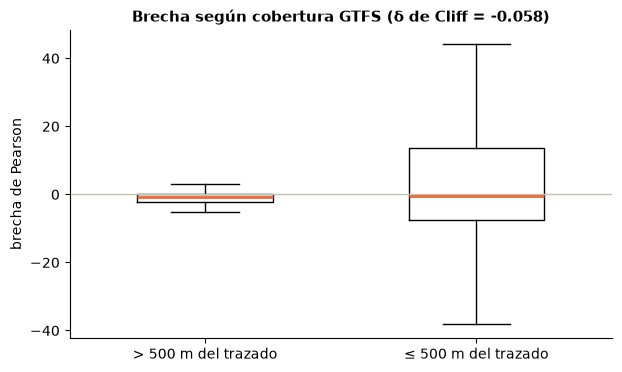

In [11]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.boxplot([no_cub["gap_pearson"], cub["gap_pearson"]], showfliers=False, widths=0.5,
           medianprops={"color": NARANJA, "lw": 2})
ax.set_xticks([1, 2], [f"> {config.COBERTURA_M} m del trazado", f"≤ {config.COBERTURA_M} m del trazado"])
ax.axhline(0, color=GRIS, lw=1)
ax.set(ylabel="brecha de Pearson", title=f"Brecha según cobertura GTFS (δ de Cliff = {M['cliff_no_cubiertas_vs_cubiertas']})")
guardar_figura(fig, "brecha_por_cobertura", FASE)
print({k: M[k] for k in ("cliff_no_cubiertas_vs_cubiertas", "top_k_no_cubiertas", "pct_zonas_no_cubiertas")})

## 6. Sensibilidad
**Tipo de datos:** numéricos (acuerdo entre rankings).

La priorización es útil solo si no depende de detalles metodológicos arbitrarios. Se recalcula la brecha con cuatro
variantes razonables y se compara con la principal mediante el Spearman de la brecha en las zonas comunes y el
índice de Jaccard del top-`TOP_K` (1 = mismas zonas prioritarias):

| Variante | Qué cambia |
|---|---|
| `mejor_tecnica_media` | la técnica de menor devianza media en la validación, en lugar de la elegida por la regla |
| `tasa_global` | esperado = tasa global × población (sin contexto territorial) |
| `antes_del_hueco` | solo consultas anteriores al hueco temporal |
| `poblacion_minima_mayor` | solo zonas con al menos `POP_MIN_SENSIBILIDAD` habitantes |

La comparación se hace en dos universos: **todas** las zonas del modelo y las zonas **sin cobertura** GTFS, que es
donde la regla de priorización de `config.py` elige las zonas a mapear.

In [12]:
grande = lambda d: d[d["population"] >= config.POP_MIN_SENSIBILIDAD]  # noqa: E731
variantes = {"mejor_tecnica_media": ev.brecha_de_tecnica(entreno, prueba, modelado["tecnica_mejor_media"]),
             "tasa_global": brecha[["h3_cell"]].assign(gap_pearson=brecha["gap_pearson_global"]),
             "antes_del_hueco": ev.brecha_de_tecnica(entreno, prueba, ELEGIDA, "query_count_before_gap"),
             "poblacion_minima_mayor": ev.brecha_de_tecnica(grande(entreno), grande(prueba), ELEGIDA)}
sin_cob = set(brecha.loc[brecha["gtfs_covered"] == 0, "h3_cell"])
solo_sin_cob = lambda d: d[d["h3_cell"].isin(sin_cob)]  # noqa: E731
sens = pd.DataFrame([{"variante": v, "universo": u, **ev.comparar_rankings(f(brecha), f(b))}
                     for v, b in variantes.items() for u, f in (("todas", lambda d: d), ("sin_cobertura", solo_sin_cob))])
guardar_tabla(sens, "sensibilidad", FASE)

,variante,universo,zonas_comunes,spearman_brecha,jaccard_top_k
0,mejor_tecnica_media,todas,1381,0.446,0.053
1,mejor_tecnica_media,sin_cobertura,755,0.429,0.333
2,tasa_global,todas,1381,0.192,0.026
3,tasa_global,sin_cobertura,755,0.254,0.143
4,antes_del_hueco,todas,1381,0.995,1.000
5,antes_del_hueco,sin_cobertura,755,0.988,1.000
6,poblacion_minima_mayor,todas,1158,0.951,0.818
7,poblacion_minima_mayor,sin_cobertura,544,0.901,0.818


⏱ sensibilidad: 2.7 s (acumulado 9 s)


,variante,universo,zonas_comunes,spearman_brecha,jaccard_top_k
0,mejor_tecnica_media,todas,1381,0.446,0.053
1,mejor_tecnica_media,sin_cobertura,755,0.429,0.333
2,tasa_global,todas,1381,0.192,0.026
3,tasa_global,sin_cobertura,755,0.254,0.143
4,antes_del_hueco,todas,1381,0.995,1.000
5,antes_del_hueco,sin_cobertura,755,0.988,1.000
6,poblacion_minima_mayor,todas,1158,0.951,0.818
7,poblacion_minima_mayor,sin_cobertura,544,0.901,0.818


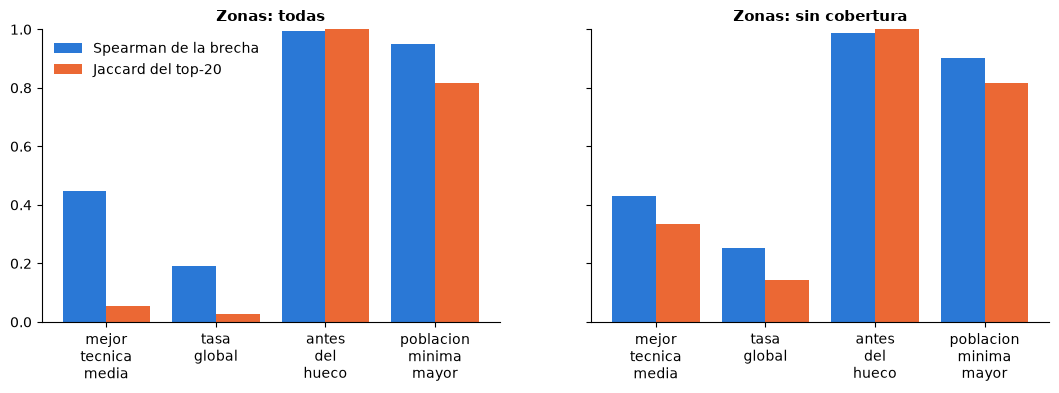

In [13]:
for r in sens.to_dict("records"):
    M[f"sens_spearman_{r['variante']}_{r['universo']}"] = r["spearman_brecha"]
    M[f"sens_jaccard_{r['variante']}_{r['universo']}"] = r["jaccard_top_k"]
fig, axes = plt.subplots(1, 2, figsize=(13, 3.8), sharey=True)
for ax, u in zip(axes, ["todas", "sin_cobertura"], strict=True):
    s, x = sens[sens["universo"] == u], np.arange(len(variantes))
    ax.bar(x - 0.2, s["spearman_brecha"], 0.4, color=AZUL, label="Spearman de la brecha")
    ax.bar(x + 0.2, s["jaccard_top_k"], 0.4, color=NARANJA, label=f"Jaccard del top-{config.TOP_K}")
    ax.set_xticks(x, s["variante"].str.replace("_", "\n"))
    ax.set(ylim=(0, 1), title=f"Zonas: {u.replace('_', ' ')}")
axes[0].legend(frameon=False)
guardar_figura(fig, "sensibilidad", FASE)
tiempo("sensibilidad")
sens

## 7. Verificaciones

### 7.1 La prueba se predijo una vez y completa
Cada zona de prueba tiene un esperado, y es el mismo que produjo la evaluación única.

In [14]:
p = brecha[brecha["partition"] == "prueba"].set_index("h3_cell")["expected"]
assert len(p) == len(prueba), "Faltan zonas de prueba"
assert np.allclose(p.loc[prueba["h3_cell"]].to_numpy(), esperado_prueba), "La brecha no usa la evaluación única"
print(f"{len(p)} zonas de prueba con esperado idéntico al de la evaluación")

352 zonas de prueba con esperado idéntico al de la evaluación


### 7.2 Integridad de la brecha
Una fila por zona del modelo, esperados positivos y conversión semanal coherente con `W_obs`.

In [15]:
assert brecha["h3_cell"].is_unique and len(brecha) == len(tabla)
assert (brecha["expected"] > 0).all() and brecha.isna().sum().sum() == 0
assert np.allclose(brecha["expected_week"] * W_OBS, brecha["expected"])
print(f"{len(brecha):,} zonas, esperados positivos, sin nulos")

1,381 zonas, esperados positivos, sin nulos


### 7.3 Coherencia con el modelado
Las predicciones de entrenamiento reproducen la calibración fuera de pliegue que reportó el modelado.

In [16]:
e = brecha[brecha["partition"] == "entrenamiento"]
calib = round(float(e["expected"].sum() / e["observed"].sum()), 3)
assert calib == modelado["oof_calibracion_elegida"], f"{calib} ≠ {modelado['oof_calibracion_elegida']}"
print(f"Calibración fuera de pliegue {calib} = resultados/04_modelado/metricas.json")

Calibración fuera de pliegue 0.977 = resultados/04_modelado/metricas.json


## 8. Cierre

In [17]:
M.update({"tecnica_evaluada": ELEGIDA, "w_obs_semanas": W_OBS, "top_k": config.TOP_K, "semilla": config.SEMILLA,
          "zonas_prueba": len(prueba)})
ruta = guardar_metricas(FASE, M)
tiempo("cierre")
print(f"{len(M)} métricas → {ruta.relative_to(config.RAIZ)}")

⏱ cierre: 0.5 s (acumulado 10 s)
36 métricas → resultados/05_evaluacion/metricas.json
